# 1) pyGIMLi ERT manager

To start, we want to get to know pyGIMLi's capabilities for ERT data, accessible through in `pygimli.physics.ert`.

This package contains **tools, modelling operators, and managers** for Electrical Resistivity Tomography (ERT) & Induced polarization (IP) data, supplying you with tools to **load, visualize, process and invert** your ERT or IP field data.

The main classes are:

* `DataContainer(ERT)` - ERT/IP-specific data container

* `ERTModelling` - Modelling operator

* `ERTManager` - data inversion and modelling for real resistivity

* `ERTIPManager` - extension to IP (either frequency or time domain)

* `TimelapseERT` - processing and inversion of timelapse ERT data

* `CrossholeERT` - timelapse ERT in crosshole environments

This notebook should provide an **overview of the most basic operations** to help you process your own field data. 
To ensure the learning outcomes, we will provide a data set in case you do not have any own data on hand. 

**But we encourage you to process your own data during this workshop!**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

from pygimli.physics import ert
import pygimli.meshtools as mt

## 1.1 Data import and sensor position definition

In [2]:
# data = pg.load("../data/AV_multigrad_2.dat")
data = pg.load("../data/AV_DD_2.dat")

coords = np.loadtxt("../data/Coordinates_ERT_P2.txt")

In [3]:
data.sensorPositions()[:5]

[[  0.     0.   299.29]
 [  1.     0.   299.2 ]
 [  2.     0.   299.1 ]
 [  3.     0.   298.98]
 [  4.     0.   298.85]]

In [4]:
data.setSensorPositions(coords) 
data.sensorPositions()[:5]

[[  0.   299.29   0.  ]
 [  1.   299.2    0.  ]
 [  2.   299.1    0.  ]
 [  3.   298.98   0.  ]
 [  4.   298.85   0.  ]]

In [5]:
data.sensorPositions()

R3Vector: n=72

## 1.2 Data container structure and data visualization

In [6]:
data

Data: Sensors: 72 data: 2949, nonzero entries: ['a', 'b', 'i', 'm', 'n', 'r', 'u', 'valid']

In [7]:
data["k"] = ert.createGeometricFactors(data, numerical=True)
data["rhoa"] = data["k"] * data["r"]

15/09/26 - 11:21:28 - pyGIMLi - INFO - Cache /Users/fwagner/git/gimli_dev/source/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.1s x 2): /Users/fwagner/Library/Caches/pygimli/7754942856585931393


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x1222e3590>)

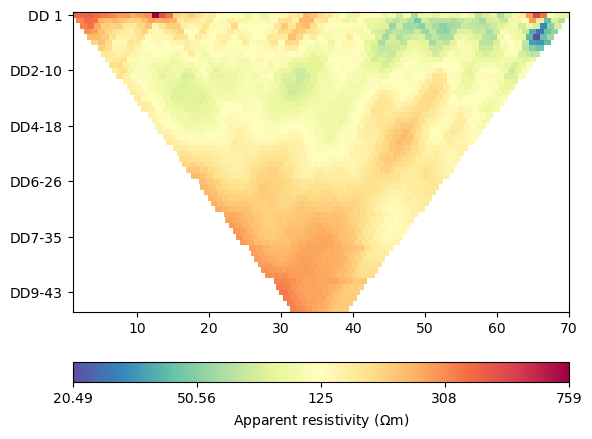

In [8]:
ert.show(data)

## 1.3 Data filtering

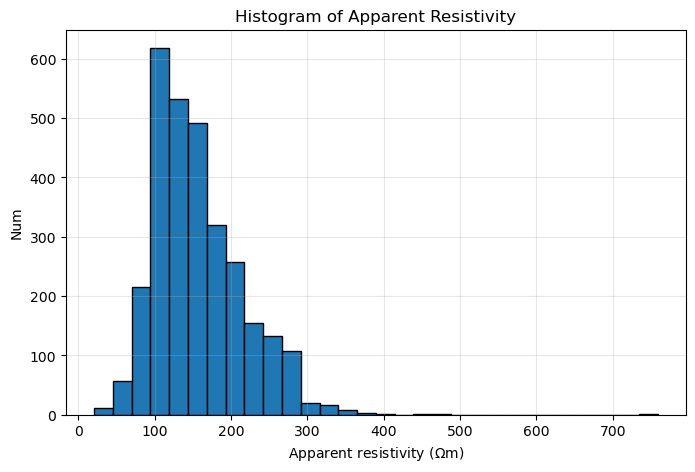

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(np.asarray(data["rhoa"]), bins=30, edgecolor="black")
plt.xlabel(r"Apparent resistivity ($\Omega \text{m}$)")
plt.ylabel("Num")
plt.title("Histogram of Apparent Resistivity")
plt.grid(alpha=0.3)
plt.show()

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x126c0c1a0>)

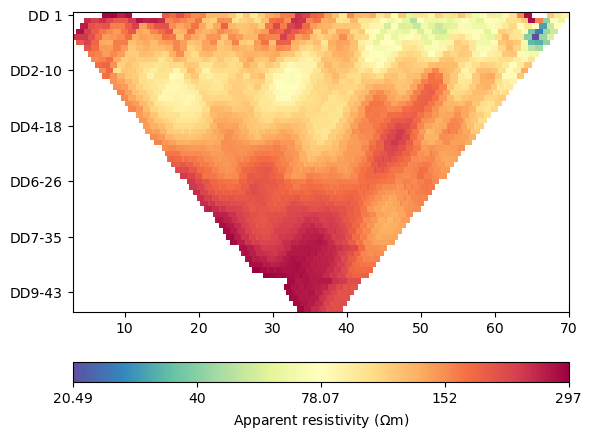

In [10]:
data.remove(data["rhoa"] > 300)
ert.show(data)

In [11]:
# data.removeSensorIdx((67,68))
# ert.show(data)

## 1.4 Error estimation and subsurface discretization

15/09/26 - 11:21:29 - pyGIMLi - INFO - Found 2 regions.
15/09/26 - 11:21:29 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


Mesh: Nodes: 2419 Cells: 4585 Boundaries: 7003


(<Axes: xlabel='$x$ in m'>, None)

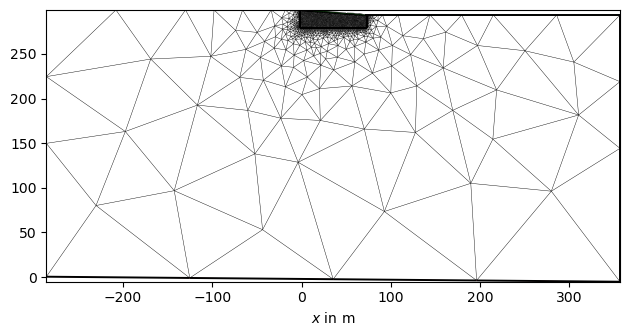

In [12]:
data["err"] = ert.estimateError(data, relativeError=0.0175, absoluteError=0.004)

mgr = ert.ERTManager(data)
plc = mt.createParaMeshPLC(data.sensorPositions(), paraDX=0.25, paraDepth=15, paraMaxCellSize=0.75)

mesh = mt.createMesh(plc)
mgr.setMesh(mesh)
print(mesh)
pg.show(mesh)

## 1.5 First inversion and quality evaluation

In [ ]:
invArgs = dict(lam = 45, robustData=False, blockyModel=False, verbose=True)

mgr = ert.ERTManager(data)
inv = mgr.invert(**invArgs)

14/09/26 - 08:33:17 - pyGIMLi - INFO - Found 2 regions.
14/09/26 - 08:33:17 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


14/09/26 - 08:33:17 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/09/26 - 08:33:17 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
14/09/26 - 08:33:17 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8738 Cells: 17092 Boundaries: 13010
14/09/26 - 08:33:17 - pyGIMLi - INFO - Use median(data values)=144.31510713659225
14/09/26 - 08:33:17 - pyGIMLi - INFO - Created startmodel from forward operator:3315, min/max=144.315107/144.315107
14/09/26 - 08:33:17 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001AACFEA7D80>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 20.49/297
min/max (error): 1.75%/1.77%
min/max (start model): 144/144
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  413.29
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   47.65 (dPhi = 88.12%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    4.97 (dPhi = 86.79%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.28 (dPhi = 41.71%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.23 (dPhi = 26.83%) lam: 45.0
-------------------------------------------------

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x1ab54578e50>)

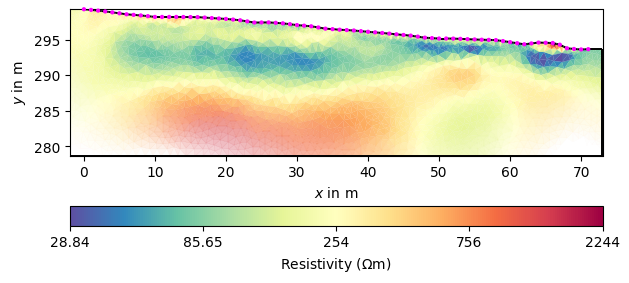

In [ ]:
mgr.showResult()

In [ ]:
# mgr.inv.relrms()

# mgr.inv.chi2()

C:\Users\Nino Menzel\AppData\Local\Temp\ipykernel_70032\2523757210.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  top = cm.get_cmap('Blues_r', 128)
C:\Users\Nino Menzel\AppData\Local\Temp\ipykernel_70032\2523757210.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bottom = cm.get_cmap('Oranges', 128)
c:\Users\Nino Menzel\optimize_ERT\.venv\Lib\site-packages\pygimli\viewer\mpl\utils.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.tight_layout()


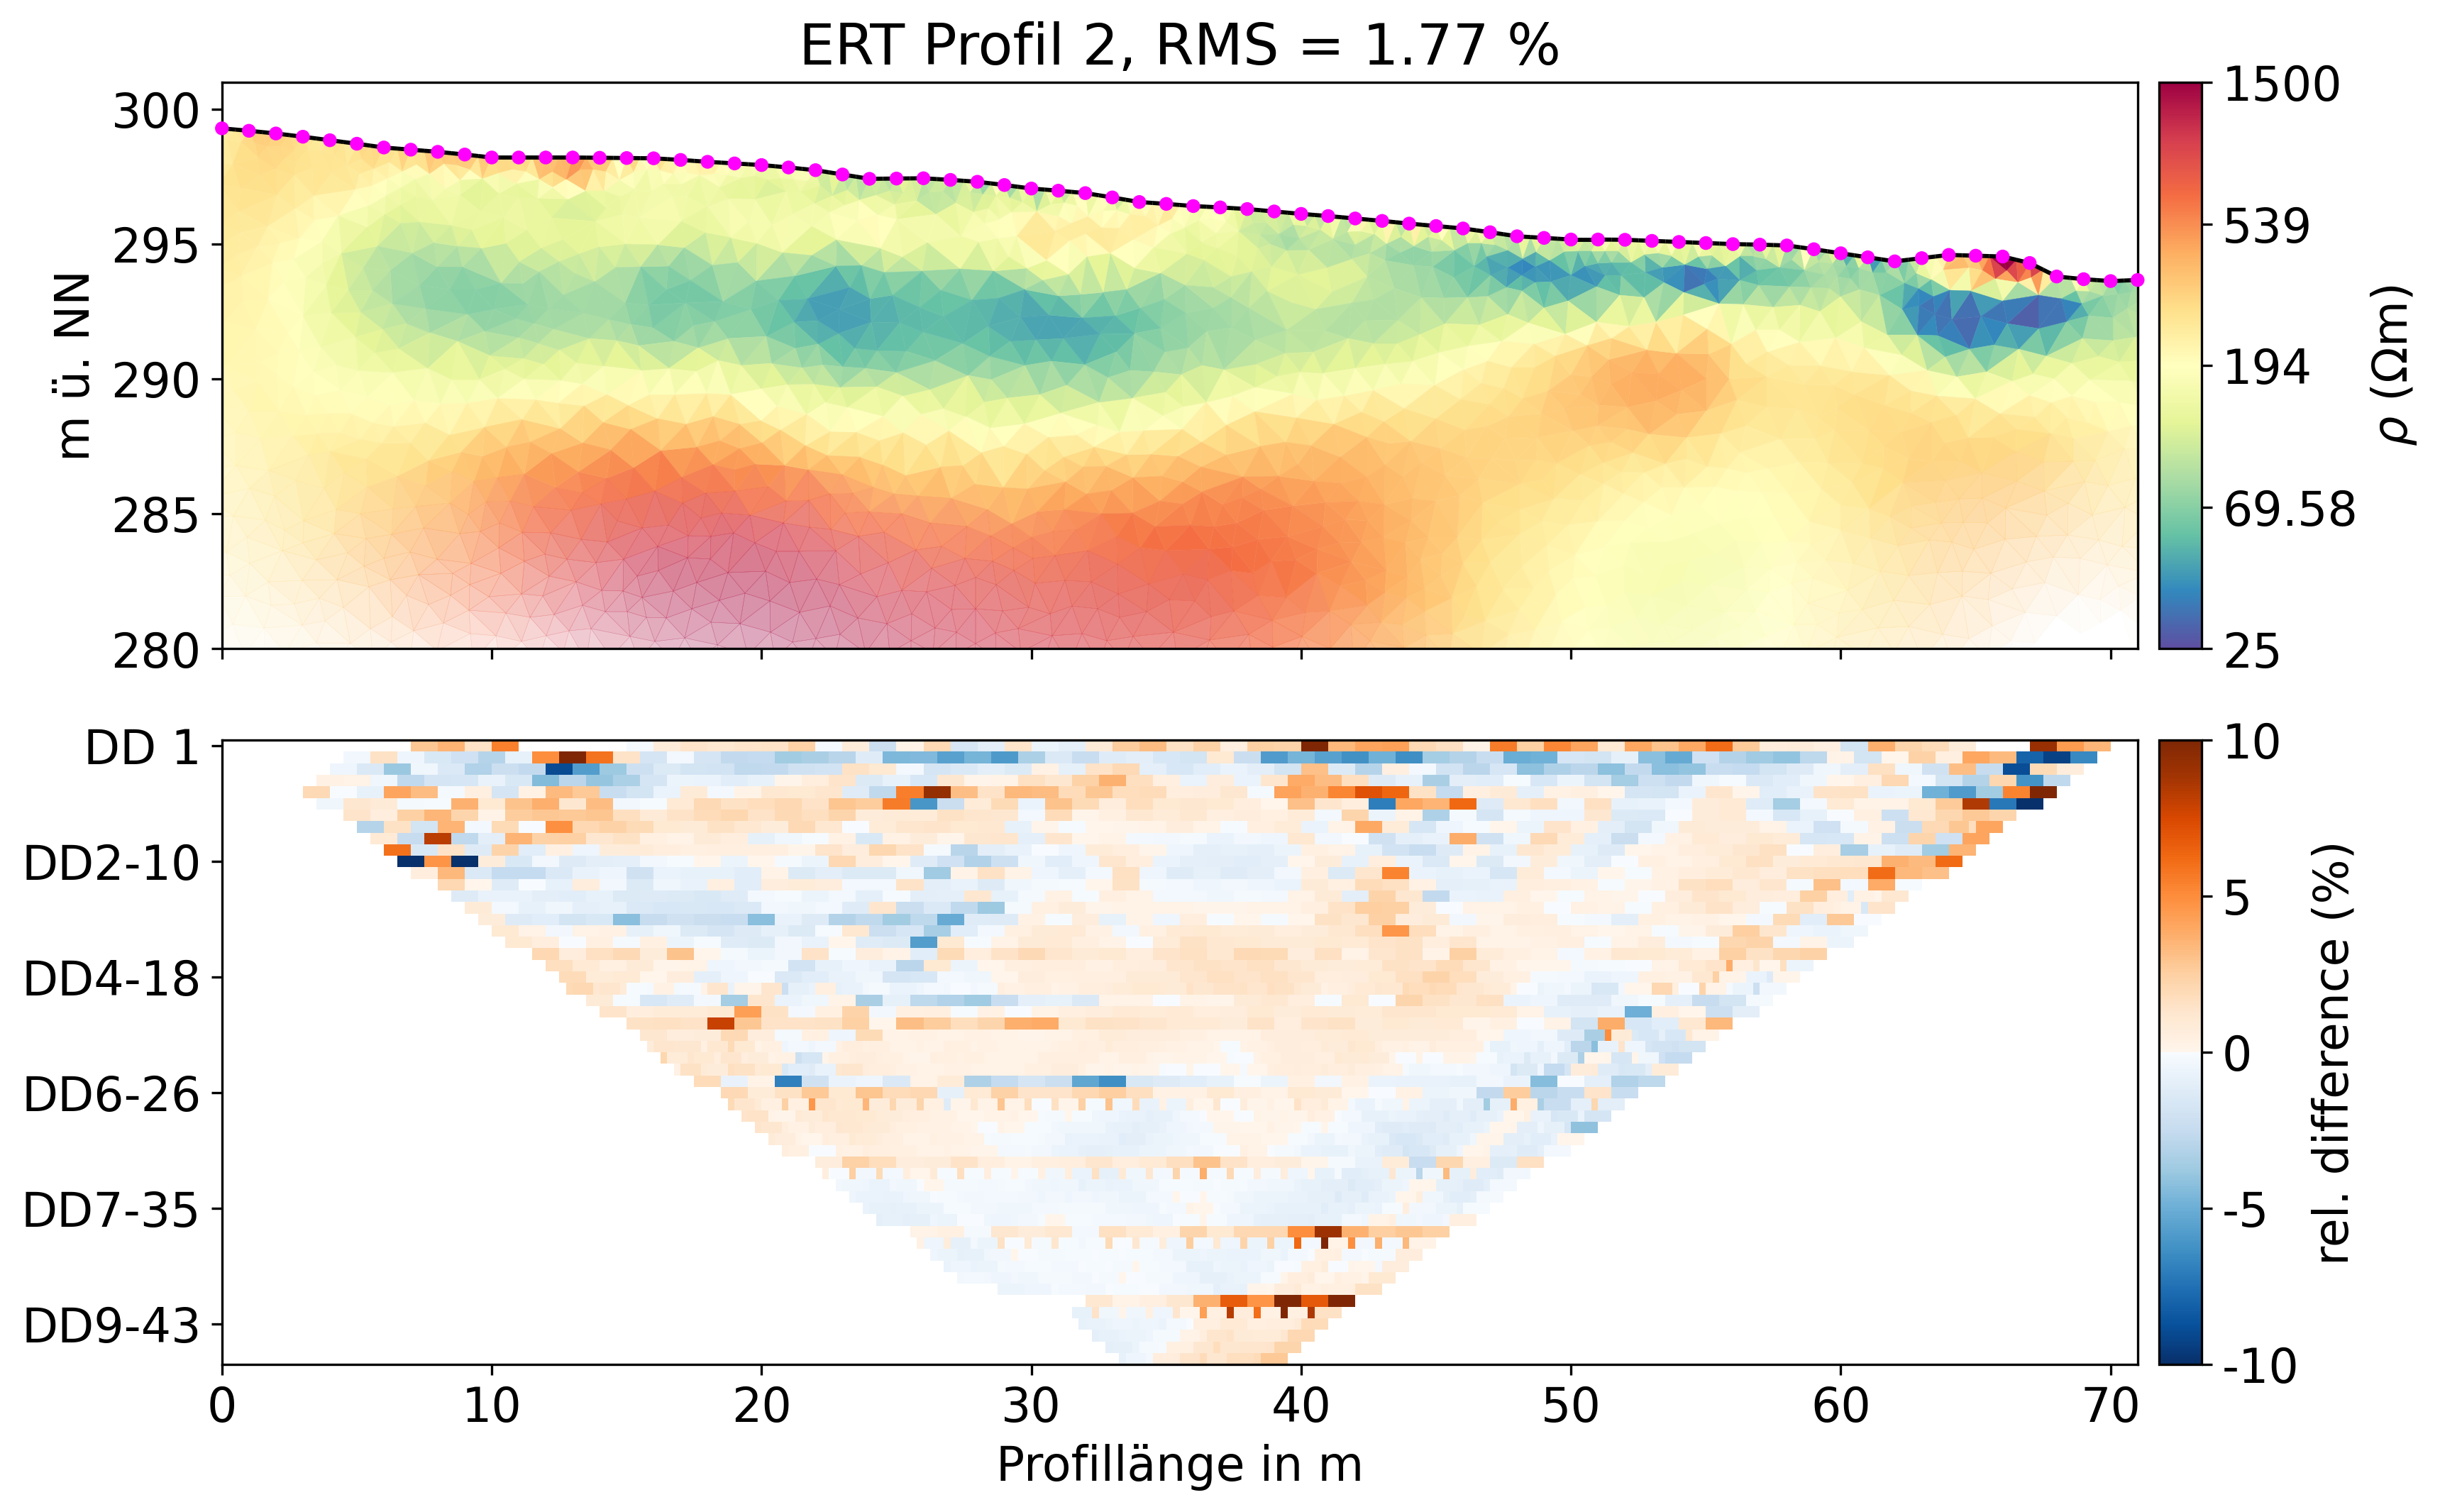

In [ ]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['font.size'] = 16

top = cm.get_cmap('Blues_r', 128)
bottom = cm.get_cmap('Oranges', 128)

newcolors = np.vstack((top(np.linspace(0, 1, 128)),
                       bottom(np.linspace(0, 1, 128))))
cmap = ListedColormap(newcolors, name='OrangeBlue')


rKW = dict(logScale=True, cMin=25, cMax=1500, 
           coverage = mgr.coverage(), orientation="vertical", 
           showTopo = True, label = r"$\rho$ ($\Omega$m)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), dpi=300, sharex=True, gridspec_kw={'hspace': .1})

mgr.showResult(ax=ax1, **rKW)
ax1.axis()
ax1.set_ylim(280, 301)
ax1.set_xlim(0, 71)
ax1.set_ylabel("m ü. NN")
ax1.set_title(f"ERT Profil 2, RMS = {mgr.inv.relrms():.2f} %")
ax1.set_xlabel("")
ax1.set_aspect("equal")

diff = (data['rhoa'] - mgr.inv.response)/mgr.inv.response * 100
ert.show(data, ax=ax2, vals=diff, cMin = -10, cMax = 10, orientation = "vertical", cMap = cmap, label = "rel. difference (%)")
ax2.set_xlabel("Profillänge in m")
ax2.set_xlim(0,71)
ax2.set_aspect("auto")

## 1.6 Save your data and mesh

In [ ]:
np.savetxt("coverage_ERT.txt", mgr.coverage())
m = pg.Mesh(mgr.paraDomain)
m['Resistivity'] = mgr.paraModel(mgr.model)
m.exportVTK(f'inv_ERT')